In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

In [8]:
data = pd.read_csv(PROJECT_ROOT / "data/raw/hvac_synthetic_dataset_v3.csv")
data.head()

,building_type,climate_zone,budget_level,area_sqft,floors,occupancy,operating_hours,building_age,outdoor_temp,humidity,insulation,glass_ratio,heat_gain,cooling_load,tonnage,energy_consumption,installation_cost,efficiency_score,recommended_hvac
0,Residential,Humid,Medium,1021.68,1.0,21.0,13.0,NaN,31.07,86.64,Good,Medium,1806.78,929.51,0.12,84.35,7204.38,94.0,Split AC
1,Residential,Cold,Medium,988.86,1.0,12.0,10.0,28.0,15.69,33.84,Average,Low,795.07,826.98,0.07,24.70,5565.45,100.0,Split AC
2,Office,Hot,Medium,29336.75,3.0,2325.0,8.0,48.0,35.54,43.33,Average,High,275672.68,239930.77,28.79,9204.61,2169512.90,34.0,Packaged Unit
3,Residential,Warm,Low,882.07,1.0,12.0,11.0,15.0,28.84,54.53,Poor,Low,1035.04,758.61,0.07,20.88,9550.15,71.0,Packaged Unit
4,Residential,Warm,Medium,1183.55,1.0,20.0,11.0,31.0,33.16,54.31,Average,Low,1623.12,1996.04,0.23,86.16,46864.46,100.0,Central Chiller


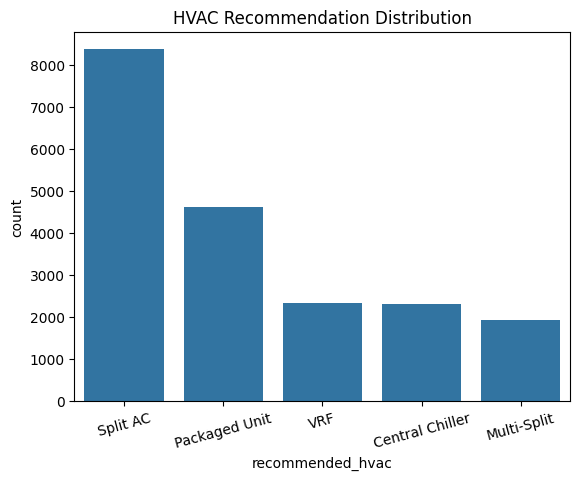

In [9]:
sns.countplot(
    data=data,
    x="recommended_hvac",
    order=data["recommended_hvac"].value_counts().index
)

plt.title("HVAC Recommendation Distribution")
plt.xticks(rotation=15)
plt.show()

In [10]:
latent_features = [
    "heat_gain",
    "cooling_load",
    "tonnage",
    "energy_consumption",
    "installation_cost",
    "efficiency_score"
]

model_df = data.drop(columns=latent_features)

In [11]:
model_df.head()

,building_type,climate_zone,budget_level,area_sqft,floors,occupancy,operating_hours,building_age,outdoor_temp,humidity,insulation,glass_ratio,recommended_hvac
0,Residential,Humid,Medium,1021.68,1.0,21.0,13.0,NaN,31.07,86.64,Good,Medium,Split AC
1,Residential,Cold,Medium,988.86,1.0,12.0,10.0,28.0,15.69,33.84,Average,Low,Split AC
2,Office,Hot,Medium,29336.75,3.0,2325.0,8.0,48.0,35.54,43.33,Average,High,Packaged Unit
3,Residential,Warm,Low,882.07,1.0,12.0,11.0,15.0,28.84,54.53,Poor,Low,Packaged Unit
4,Residential,Warm,Medium,1183.55,1.0,20.0,11.0,31.0,33.16,54.31,Average,Low,Central Chiller


In [12]:
model_df.isna().sum()

building_type       392
climate_zone        371
budget_level        418
area_sqft           386
floors              397
occupancy           390
operating_hours     423
building_age        398
outdoor_temp        403
humidity            404
insulation          362
glass_ratio         413
recommended_hvac    390
dtype: int64

In [15]:
print(model_df["recommended_hvac"].value_counts(normalize=True) * 100)

recommended_hvac
Split AC           42.728200
Packaged Unit      23.590005
VRF                11.988781
Central Chiller    11.805201
Multi-Split         9.887812
Name: proportion, dtype: float64


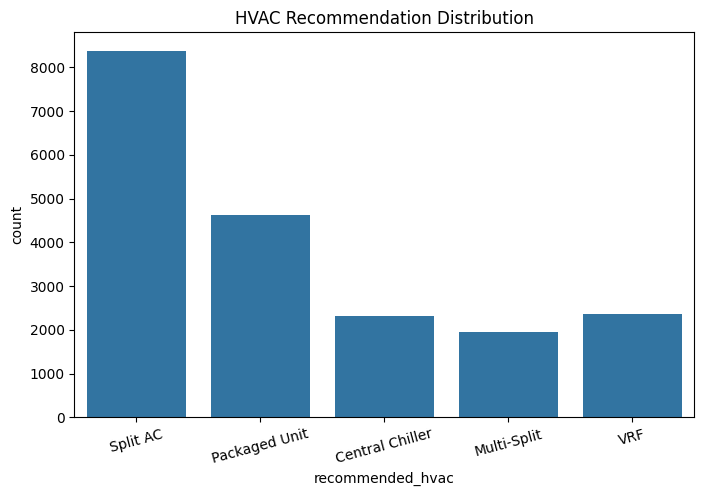

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=model_df,
    x="recommended_hvac"
)

plt.title("HVAC Recommendation Distribution")

plt.xticks(rotation=15)

plt.show()

In [ ]:
missing = (
    model_df.isnull().mean().sort_values(ascending=False) * 100
)

print(missing)

operating_hours     2.115
budget_level        2.090
glass_ratio         2.065
humidity            2.020
outdoor_temp        2.015
building_age        1.990
floors              1.985
building_type       1.960
occupancy           1.950
recommended_hvac    1.950
area_sqft           1.930
climate_zone        1.855
insulation          1.810
dtype: float64


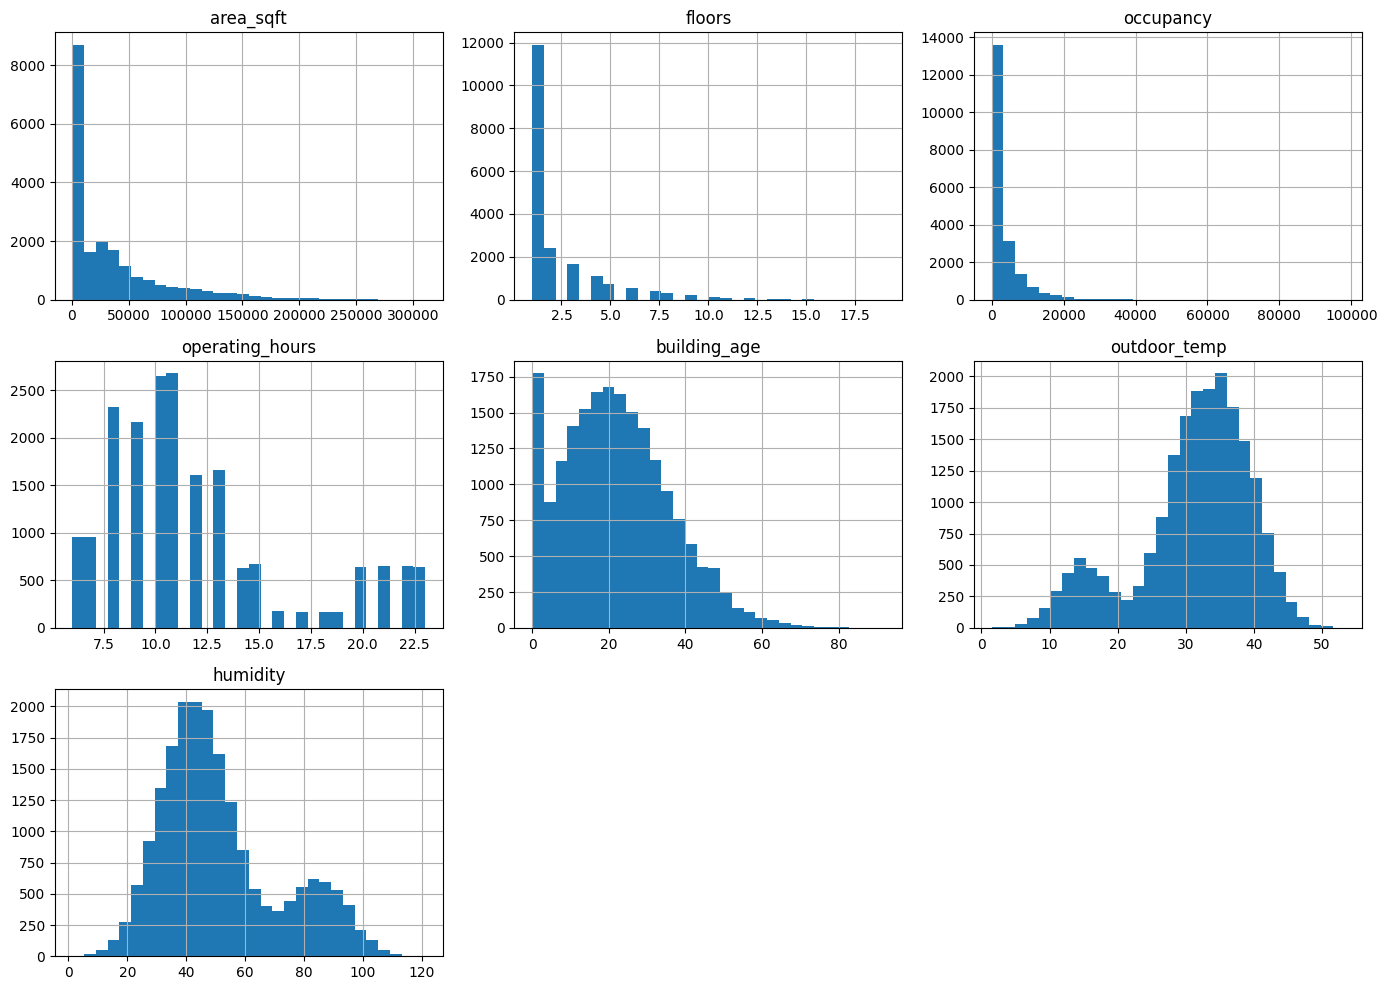

In [20]:
numerical_cols = [
    "area_sqft",
    "floors",
    "occupancy",
    "operating_hours",
    "building_age",
    "outdoor_temp",
    "humidity"
]

model_df[numerical_cols].hist(
    figsize=(14,10),
    bins=30
)

plt.tight_layout()

plt.show()

In [21]:
categorical_cols = [
    "building_type",
    "climate_zone",
    "budget_level",
    "insulation",
    "glass_ratio"
]

for col in categorical_cols:

    print("\n", col)

    print(model_df[col].value_counts(normalize=True))


 building_type
building_type
Residential    0.402693
Office         0.248062
Retail         0.148766
Industrial     0.100316
Hospital       0.100163
Name: proportion, dtype: float64

 climate_zone
climate_zone
Hot      0.344796
Warm     0.302461
Humid    0.203474
Cold     0.149269
Name: proportion, dtype: float64

 budget_level
budget_level
Medium    0.454244
Low       0.350322
High      0.195435
Name: proportion, dtype: float64

 insulation
insulation
Average      0.397495
Poor         0.298707
Good         0.247632
Excellent    0.056167
Name: proportion, dtype: float64

 glass_ratio
glass_ratio
Low       0.418696
Medium    0.364476
High      0.216827
Name: proportion, dtype: float64


In [22]:
pd.crosstab(
    model_df["building_type"],
    model_df["recommended_hvac"],
    normalize="index"
)

recommended_hvac,Central Chiller,Multi-Split,Packaged Unit,Split AC,VRF
building_type,,,,,
Hospital,0.646266,0.059129,0.116701,0.058610,0.119295
Industrial,0.102804,0.071132,0.548287,0.073728,0.204050
Office,0.079091,0.216870,0.277030,0.259781,0.167228
Residential,0.019714,0.041361,0.057596,0.831336,0.049994
Retail,0.104159,0.101363,0.521846,0.102412,0.170220


In [23]:
pd.crosstab(
    model_df["budget_level"],
    model_df["recommended_hvac"],
    normalize="index"
)

recommended_hvac,Central Chiller,Multi-Split,Packaged Unit,Split AC,VRF
budget_level,,,,,
High,0.156675,0.098055,0.168132,0.397549,0.179590
Low,0.109522,0.100730,0.194904,0.490836,0.104008
Medium,0.107360,0.097860,0.297356,0.392240,0.105185


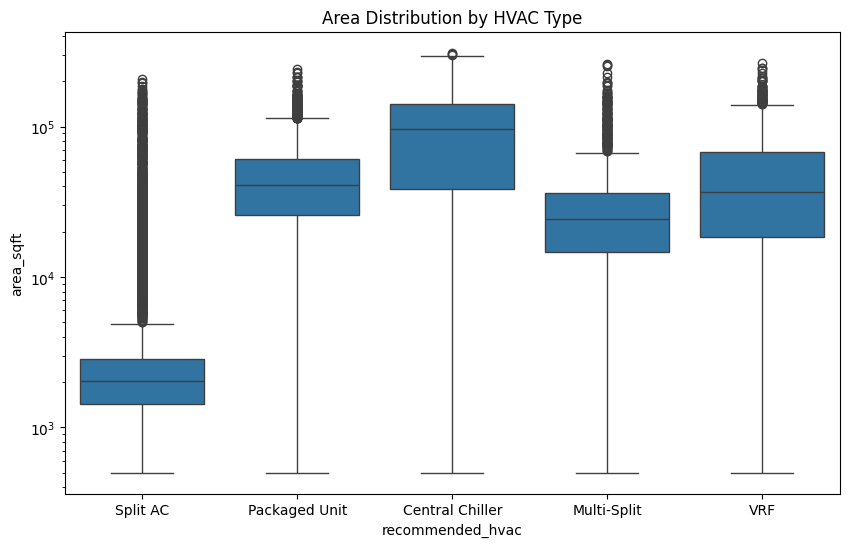

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=model_df,
    x="recommended_hvac",
    y="area_sqft"
)

plt.yscale("log")

plt.title("Area Distribution by HVAC Type")

plt.show()

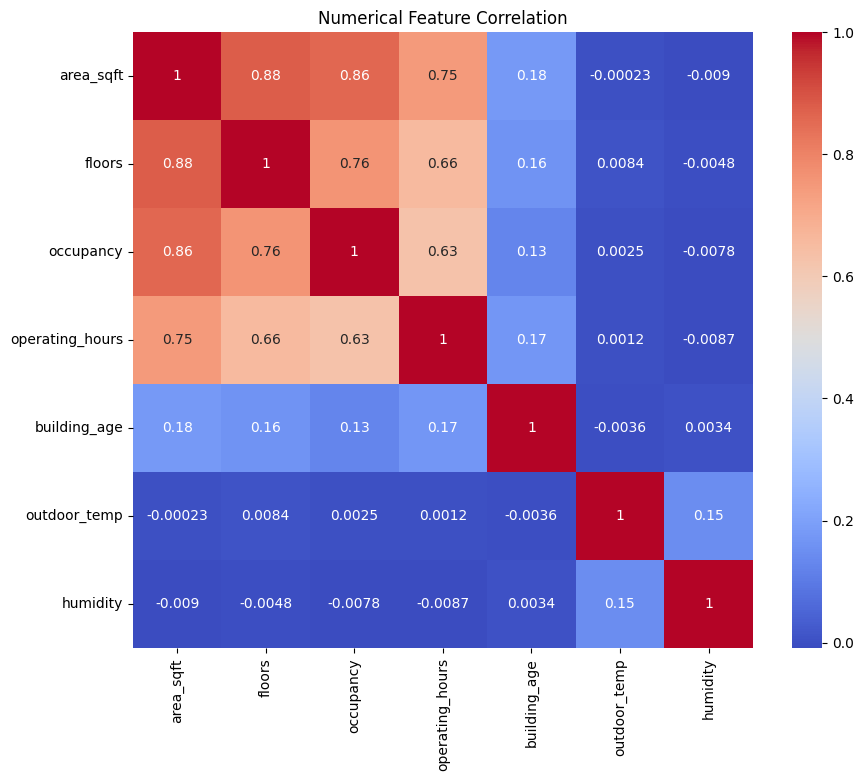

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(
    model_df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")

plt.show()